In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score

# 1. Загрузите данные из файла abalone.csv. Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим измерениям.

In [3]:
data = pd.read_csv('abalone.csv')

# 2. Преобразуйте признак Sex в числовой: значение F должно перейти в -1, I - в, M - в 1. Если вы используете Pandas, то подойдет следующий код: data[’Sex’] = data[’Sex’].map(lambda x: 1 if x == ’M’ else (-1 if x == ’F’ else 0))

In [4]:
sex_mapping = {'M': 1, 'F': -1, 'I': 0}
data['Sex'] = data['Sex'].map(sex_mapping)

# 3. Разделите содержимое файлов на признаки и целевую переменную. В последнем столбце записана целевая переменная, в остальных - признаки.

In [5]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

# 4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor) с различным числом деревьев: от 1 до 50 (random_state=1). Для каждого из вариантов оцените качество работы полученного леса на кросс-валидации по 5 блокам. Используйте параметры "random_state=1"и "shuffle=True"при создании генератора кроссвалидации sklearn.cross_validation.KFold. В качестве меры качества воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).

In [6]:
cv_splitter = KFold(n_splits=5, shuffle=True, random_state=1)

# 5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52. Это количество и будет ответом на задание.

In [7]:
tree_counts = range(1, 51)
r2_scores = []

best_n = None

for n_trees in tree_counts:
    # Создаем случайный лес с n деревьями
    rf_model = RandomForestRegressor(n_estimators=n_trees, random_state=1)

    # Кросс-валидация (метрика R²)
    cv_scores = cross_val_score(rf_model, X, y, cv=cv_splitter, scoring='r2')
    mean_r2 = cv_scores.mean()
    r2_scores.append(mean_r2)

    # Проверяем, достигли ли порога 0.52
    if mean_r2 > 0.52 and best_n is None:
        best_n = n_trees

print(f"Минимальное количество деревьев для R² > 0.52: {best_n}")

Минимальное количество деревьев для R² > 0.52: 21


# 6. Обратите внимание на изменение качества по мере роста числа деревьев. Ухудшается ли оно?

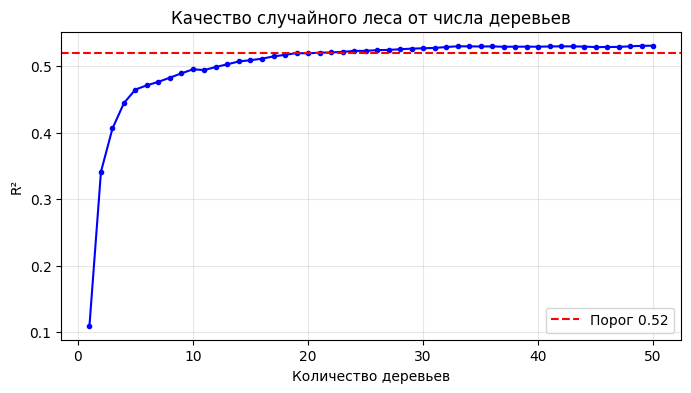


Качество НЕ ухудшается, а стабилизируется после ~20 деревьев.


In [9]:
import matplotlib.pyplot as plt

n_range = list(range(1, 51))
all_scores = []

for n in n_range:
    rf = RandomForestRegressor(n_estimators=n, random_state=1)
    score = np.mean(cross_val_score(rf, X, y, cv=cv_splitter, scoring='r2'))
    all_scores.append(score)

plt.figure(figsize=(8, 4))
plt.plot(n_range, all_scores, 'b-', marker='o', markersize=3)
plt.axhline(y=0.52, color='r', linestyle='--', label='Порог 0.52')
plt.xlabel('Количество деревьев')
plt.ylabel('R²')
plt.title('Качество случайного леса от числа деревьев')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nКачество НЕ ухудшается, а стабилизируется после ~20 деревьев.")